# Testing Performance of Multiple OT variants
Having tested correspondence between multiple resolutions and thresholds for exact OT, we will now perform a similar kind of analysis but with different variants of OT on 8 Mb at a 0% threshold.

## Importing

In [1]:
### Importing Cooler Files ###
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
from time import perf_counter
import ot
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, bin_contact_map, get_cool_name, hic_ot_source_to_targets

# Importing data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'
coolers = import_cool_dir(data_dir, 1_000_000)

# Extracting chromosome 1
chr1s = []
map_names = []
for clr in coolers:
    chr1s.append(fetch_region(clr, '1'))
    map_names.append(get_cool_name(clr).split("_")[1])

# Importing SCC data
scc_file = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/mouse_scc_chr1/mouse_chr1_scc.csv'
scc_scores_1mb = pd.read_csv(scc_file, index_col=0)
scc_scores_flatten = scc_scores_1mb.values.flatten()

In [2]:
### Binning to 8 Mb ###
chr1_binned_8mb = []
for chr1 in chr1s:
    chr1_binned_8mb.append(bin_contact_map(chr1, 8))

### Binning to 4 Mb ###
chr1_binned_4mb = []
for chr1 in chr1s:
    chr1_binned_4mb.append(bin_contact_map(chr1, 4))

### Binning to 2 Mb ###
chr1_binned_2mb = []
for chr1 in chr1s:
    chr1_binned_2mb.append(bin_contact_map(chr1, 2))

### Binning to 1 Mb ###
chr1_binned_1mb = []
for chr1 in chr1s:
    chr1_binned_1mb.append(bin_contact_map(chr1, 1))

## Helper Functions

In [3]:
def compare_to_scc(ot_results : list, threshold : int, resolution : int, ot_type : str = "balanced", 
                   reg_m: float = None, reg: float = None, plot: bool = False):
    ''' 
        Converts ot results to a pandas dataframe and uses 
        said dataframe to compare ot loss to scc scores.
        
        This function is very specific to this notebook.

        Parameters
        ----------
        ot_results : list
            List of ot results orderded like map_names.
        threshold : int
            The threshold tested. Used for figure title.
        resolution : int
            The resolution tested. Used for figure title.
        ot_type : str
            Type of ot used. Used for figure title.
            Default = "balanced"
        reg_m : float
            Unbalancing parameter used. Used for figure title.
            Default = None.
        reg : float
            Regularization parameter used. Used for figure title.
            Default = None.
        plot : bool
            Determines if the results are plotted.
            Default = False
        
        Returns
        -------
        results_df : pd.DataFrame
            Dataframe of ot results with indices based on map_names.
        rsqr : float
            R^2 values of the fit with SCC scores.
    '''

    # Convert to dataframe
    results_df = pd.DataFrame(ot_results, index=map_names, columns=map_names)

    # SCC comparison regression
    ot_results_flatten = results_df.values.flatten()
    regression = linregress(ot_results_flatten, scc_scores_flatten)
    slope = regression.slope
    intercept = regression.intercept
    rsqr = regression.rvalue**2

    # Plotting SCC comparison
    if plot:
        plt.scatter(ot_results_flatten, scc_scores_flatten, label="Data")
        plt.plot(ot_results_flatten, intercept + slope * ot_results_flatten, color='red',
                label=f'Linear fit (R\u00b2 = {rsqr:.3f})')
        plt.xlabel("OT loss")
        plt.ylabel("SCC score")
        if ot_type.lower() == "balanced":
            if reg == None:
                plt.title(f"{ot_type} OT loss to SCC score (res={resolution}Mb, threshold={threshold})")
            else:
                plt.title(f"{ot_type} OT loss (reg={reg}) to SCC score (res={resolution}Mb, threshold={threshold})")
        else:
            if reg == None:
                plt.title(f"{ot_type} OT loss to SCC score (res={resolution}Mb, threshold={threshold}, reg_m={reg_m})")
            else:
                plt.title(f"{ot_type} OT loss (reg={reg}) to SCC score (res={resolution}Mb, threshold={threshold}, reg_m={reg_m})")
        plt.legend()
        plt.grid(alpha=0.3)

    return results_df, rsqr

def save_df_to_csv(results_df : pd.DataFrame, resolution : int, threshold : int, ot_type : str = "balanced", reg_m: float = None, 
                   reg: float = None):
    ''' 
        Saves ot results dataframe to a file in specific folder.
        
        This function is very specific to this notebook.

        Parameters
        ----------
        results_df : pd.DataFrame
            Dataframe of ot results.
        resolution : int
            The resolution tested. Used for file name.
        threshold : int
            The threshold tested. Used for file name.
        ot_type : str
            Type of ot used. Used for file name.
            Default = "balanced"
        reg_m : float
            Unbalanced parameter used. Used for file name.
            Default = None
        reg : float
            Regularization parameter. Used for file name.
            Default = None
        
        Returns
        -------
        None
    '''

    save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Bulk-to-bulk'
    if ot_type == "balanced":
        if reg == None:
            file_name = f"{ot_type}_bulk_to_bulk_{resolution}mb_{threshold}.csv"
        else:
            file_name = f"{ot_type}_reg_{reg}_bulk_to_bulk_{resolution}mb_{threshold}.csv"
    else:
        if reg == None:
            file_name = f"{ot_type}_{reg_m}_bulk_to_bulk_{resolution}mb_{threshold}.csv"
        else:
            file_name = f"{ot_type}_{reg_m}_reg_{reg}_bulk_to_bulk_{resolution}mb_{threshold}.csv"
    results_df.to_csv(f"{save_dir}/{file_name}")

    return

def calculate_correspondence(results_df1 : pd.DataFrame, results_df2 : pd.DataFrame, plot : bool = False):
    '''
        Calculates linear R^2 value between two ot result dataframes.

        Parameters
        ----------
        results_df1 : pd.DataFrame
            Dataframe of ot results.
        results_df2 : pd.DataFrame
            Dataframe of ot results.
        plot : bool
            Controls whether the results are plotted.
            Default = False.
        
        Returns
        -------
        rsqr : float
            R^2 value for linear regression between the two datasets.
    '''

    # Flatten values
    flatten1 = results_df1.values.flatten()
    flatten2 = results_df2.values.flatten()

    # Linear regression
    regression = linregress(flatten1, flatten2)
    intercept = regression.intercept
    slope = regression.slope
    rsqr = regression.rvalue**2

    # Plotting regression
    if plot:
        plt.scatter(flatten1, flatten2, label="Data")
        plt.plot(flatten1, intercept + slope * flatten1, color='red',
                label=f'Linear fit (R\u00b2 = {rsqr:.3f})')
        plt.xlabel("OT loss df1")
        plt.ylabel("OT loss df2")
        plt.legend()
        plt.grid(alpha=0.3)

    return rsqr

def ot_and_scc_comp(chrs: list, resoltuion: int, cutoff: float = 0, thres_type: str = "raw", norm: str = "sum", unbalanced: float = None,
                    reg: float = None, plot: bool = False):
    '''
        Performs specified version of OT between all datasets in chrs,
        saves these results to a csv, and compares these results to the
        SCC scores.

        This function is specific to this notebook.

        Parameters
        ----------
        chrs : list
            List of datasets to be analyzed.
        resolution : int
            The resolution tested. Used for figure title.
        cut_off : float
            The cut-off value for setting a threshold in the source and 
            target datasets.
            Default = 0.
        thres_type : str
            The kind of threshold to be set.
            Options include 'raw' and 'percentile'.
            Default = 'raw'.
        norm : str
            Type of normalization to use. Options include "none",
            "max" and "sum".
            Default = 'sum'.
        unbalanced : float
            Unbalanced parameter if UOT should be used.
            Default = None, uses exact OT instead.
        reg : float
            Entropic regularization term.
            Default = None, uses exact OT instead.
        plot : bool
            Determines if the results of the scc comparison are plotted.
            Default = False
        
        Returns
        -------
        ot_results : pd.DataFrame
            Dataframe with OT results
        calc_time : float
            Time it took for OT to be performed.
        scc_r2 : float
            R^2 values of the fit with SCC scores.
    '''
    # TODO: add regularization functionality

    # Determine OT type
    if unbalanced == None:
        ot_type = "balanced"
    else:
        ot_type = "unbalanced"

    # OT
    ot_results_list = []
    start_time = perf_counter()
    for chr in chrs:
        ot_results_list.append(hic_ot_source_to_targets(chr, chrs, cutoff, thres_type, norm, unbalanced, reg))
    end_time = perf_counter()
    calc_time = end_time - start_time

    # Calculate SCC R^2 and save
    ot_results, scc_r2 = compare_to_scc(ot_results_list, cutoff, resoltuion, ot_type, unbalanced, reg, plot)
    save_df_to_csv(ot_results, resoltuion, cutoff, ot_type, unbalanced, reg)

    return ot_results, calc_time, scc_r2

def update_time_file(calc_time: int, r2: float, res: int, threshold: int):
    '''
        Updates the computation time csv file to keep track of
        computation times and r2 even if the kernel crashes.

        Parameters
        ----------
        calc_time : int
            Calculation time to be saved
        r2 : float
            Calculated r2 value to be saved
        res : int
            Resolution of the OT performed
        threshold : int
            Threshold for the OT performed

        Returns
        -------
        df_calc : pd.DataFrame
            Dataframe containing computation times.
        df_r2 : pd.Dataframe
            Dataafraame containing r2 values
    '''
    
    # Initialize csv path
    calc_path = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Bulk-to-bulk/unbalanced_0.1_comptimes.csv'
    r2_path = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Bulk-to-bulk/unbalanced_0.1_r2values.csv'

    # Cast to strings to ensure proper indexing
    res = str(res)
    threshold = str(threshold)

    # Make or import csv
    if os.path.exists(calc_path):
        df_calc = pd.read_csv(calc_path, index_col=0)
        df_calc.index = df_calc.index.astype(str)
    else:
        df_calc = pd.DataFrame()

    if os.path.exists(r2_path):
        df_r2 = pd.read_csv(r2_path, index_col=0)
        df_r2.index = df_r2.index.astype(str)
    else:
        df_r2 = pd.DataFrame()

    # Create column 
    if res not in df_calc.columns:
        df_calc[res] = pd.Series(dtype="float")

    if res not in df_r2.columns:
        df_r2[res] = pd.Series(dtype="float")

    # Insert value in row
    df_calc.at[threshold, res] = calc_time

    df_r2.at[threshold, res] = r2

    # Save to CSV
    df_calc.to_csv(calc_path)

    df_r2.to_csv(r2_path)

    return df_calc, df_r2

## Balanced, No Regularization

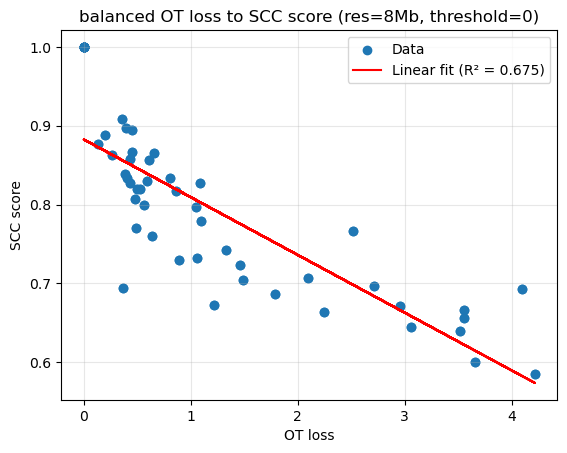

In [4]:
### Balanced OT, No Regularization ###
exact_ot_results, exact_time, exact_scc_r2 = ot_and_scc_comp(chr1_binned_8mb, 8, 0, plot = True)

## Unbalanced, No Regularization


In [5]:
### Setting values and lists ###
unbalanced_parms = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000]
uot_results_list = []
uot_times_list = []
uot_scc_r2_list = []

In [6]:
### Unbalanced OT, No Regularization ###
for reg_m in unbalanced_parms:
    uot_results, uot_time, uot_scc_r2 = ot_and_scc_comp(chr1_binned_8mb, 8, 0, norm="max", unbalanced=reg_m)
    uot_results_list.append(uot_results)
    uot_times_list.append(uot_time)
    uot_scc_r2_list.append(uot_scc_r2)

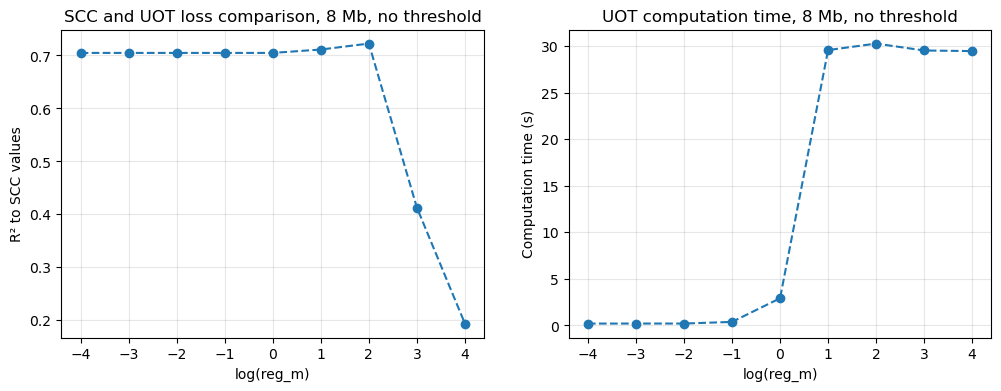

In [7]:
### Plotting ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R2 values
axes[0].plot(np.log10(unbalanced_parms), uot_scc_r2_list, 'o--')
axes[0].set_xlabel("log(reg_m)")
axes[0].set_ylabel("R\u00b2 to SCC values")
axes[0].set_title("SCC and UOT loss comparison, 8 Mb, no threshold")
axes[0].grid(alpha=0.3)

# Computation times
axes[1].plot(np.log10(unbalanced_parms), uot_times_list, 'o--')
axes[1].set_xlabel("log(reg_m)")
axes[1].set_ylabel("Computation time (s)")
axes[1].set_title("UOT computation time, 8 Mb, no threshold")
axes[1].grid(alpha=0.3)

In [13]:
### Saving to df ###
uot_regm_df = pd.DataFrame({
    "reg_m": unbalanced_parms,
    "computation_time": uot_times_list,
    "R2": uot_scc_r2_list
})

uot_regm_df.to_csv('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Bulk-to-bulk/uot_regm_results.csv',
                   index = False)

## Balanced, Regularization

In [8]:
### Setting values and lists ###
reg_list = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
balanced_reg_results_list = []
balanced_reg_times_list = []
balanced_reg_scc_r2_list = []

In [9]:
### Balanced OT, Regularization ###
for reg in reg_list:
    results, time, scc_r2 = ot_and_scc_comp(chr1_binned_8mb, 8, 0, reg=reg)
    balanced_reg_results_list.append(results)
    balanced_reg_times_list.append(time)
    balanced_reg_scc_r2_list.append(scc_r2)

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:902: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/backend.py:1203: RuntimeWarning: overflow encountered in exp
  return np.exp(a)


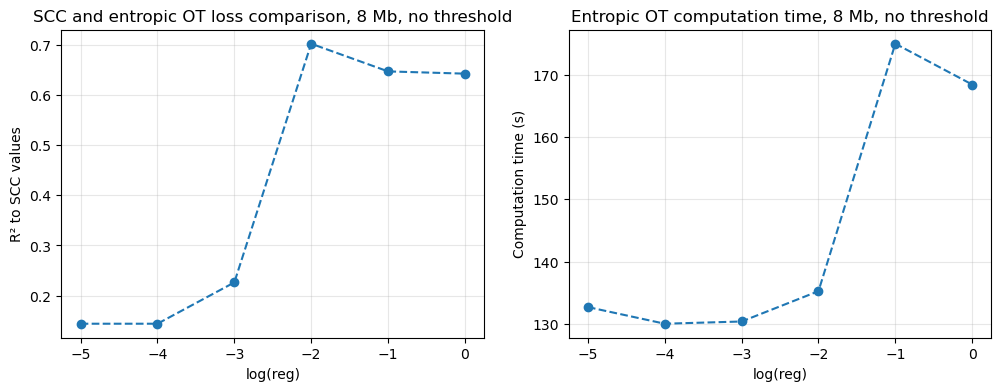

In [10]:
### Plotting ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R2 values
axes[0].plot(np.log10(reg_list), balanced_reg_scc_r2_list, 'o--')
axes[0].set_xlabel("log(reg)")
axes[0].set_ylabel("R\u00b2 to SCC values")
axes[0].set_title("SCC and entropic OT loss comparison, 8 Mb, no threshold")
axes[0].grid(alpha=0.3)

# Computation times
axes[1].plot(np.log10(reg_list), balanced_reg_times_list, 'o--')
axes[1].set_xlabel("log(reg)")
axes[1].set_ylabel("Computation time (s)")
axes[1].set_title("Entropic OT computation time, 8 Mb, no threshold")
axes[1].grid(alpha=0.3)

In [14]:
### Saving to df ###
reg_df = pd.DataFrame({
    "reg": reg_list,
    "computation_time": balanced_reg_times_list,
    "R2": balanced_reg_scc_r2_list
})

reg_df.to_csv('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Bulk-to-bulk/balanced_reg_results.csv',
                   index = False)

## Testing Unbalanced Res 8 - 2 Mb

In [6]:
resolutions = [1]
thresholds = [75, 50, 25, 0]

for res in resolutions:
    if res == 8:
        chr_binned = chr1_binned_8mb
    elif res == 4:
        chr_binned = chr1_binned_4mb
    elif res == 2:
        chr_binned = chr1_binned_2mb
    else:
        chr_binned = chr1_binned_1mb
    
    for thres in thresholds:
        if thres == 0:
            norm_type = "raw"
        else:
            norm_type = "percentile"
        
        results, time, r2 = ot_and_scc_comp(chr_binned, res, thres, norm_type, "max", 1e-1)
        update_time_file(time, r2, res, thres)

: 